# Bvarta Bahari — 03. Evaluasi Rute Eksisting

Menilai kelayakan finansial 16 rute eksisting: membandingkan pendapatan dengan biaya
operasional, lalu mengubahnya jadi keputusan (rute mana dipertahankan, dioptimasi, atau
dirancang ulang). Notebook ini menyambung hasil forecast permintaan (notebook 02): rute padat
yang sering sold-out adalah kandidat penambahan kapasitas, sementara rute rugi butuh perlakuan berbeda.

### Metode & asumsi
- **Pendapatan bulanan per rute** = `tickets_sold` bulanan × harga rata-rata tiket. Data hanya
  mencatat total tiket terjual, bukan rinciannya per kelas, jadi harga rata-rata dihitung dari
  asumsi bauran kelas (70% Ekonomi / 25% Bisnis / 5% Kabin bila ada kelas Kabin; selain itu
  80/20). Asumsi ini diuji ketahanannya di bagian 2.
- **Biaya** = `total_opex_idr` bulanan (bahan bakar + kru + jasa pelabuhan + perawatan).
- **Margin** = pendapatan − biaya, dalam rupiah dan persen. Ini margin operasional, belum
  termasuk biaya modal/penyusutan kapal.
- **Batasan domain dijaga:** rute `wajib` (R01–R03) tidak boleh dihapus walau rugi; opsinya
  hanya optimasi cara operasinya.

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
DATA = "../data/"
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.6)

orders = pd.read_csv(DATA+"orders_history_daily.csv", parse_dates=["date"])
prices = pd.read_csv(DATA+"route_prices.csv")
opex   = pd.read_csv(DATA+"route_opex_monthly.csv")
routes = pd.read_csv(DATA+"routes_existing.csv")
fleet  = pd.read_csv(DATA+"fleet.csv")
print("loaded |", orders.shape, "orders |", opex.month.nunique(), "bulan opex | 16 rute")

loaded | (17536, 7) orders | 36 bulan opex | 16 rute


## 1. Konstruksi pendapatan, biaya, & margin per rute

Pendapatan dibangun transparan dari jumlah tiket terjual dikali harga rata-rata tiket (bauran
kelas). Biaya diambil langsung dari opex bulanan. Tabel diurutkan dari margin terburuk.

In [2]:
def avg_price(g):
    p = g.set_index("ticket_class").price_idr
    if "Kabin" in p.index:
        bl = .70*p["Ekonomi"] + .25*p["Bisnis"] + .05*p["Kabin"]
    else:
        bl = .80*p["Ekonomi"] + .20*p["Bisnis"]
    return pd.Series({"price_eco": p["Ekonomi"], "price_blend": bl})

pb = prices.groupby("route_id").apply(avg_price).reset_index()

o = orders.copy(); o["month"] = o.date.dt.strftime("%Y-%m")
mt = o.groupby(["route_id","month"]).tickets_sold.sum().rename("tickets").reset_index()
m  = (mt.merge(pb, on="route_id")
        .merge(opex[["route_id","month","total_opex_idr"]], on=["route_id","month"]))
m["rev_blend"] = m.tickets * m.price_blend
m["rev_eco"]   = m.tickets * m.price_eco

pl = m.groupby("route_id").agg(rev=("rev_blend","mean"), opex=("total_opex_idr","mean"),
                               tickets=("tickets","mean")).round(0)
pl["margin"]     = (pl.rev - pl.opex).round(0)
pl["margin_pct"] = (pl.margin / pl.rev * 100).round(1)
pl = pl.merge(routes.set_index("route_id")[["route_type","frequency_per_week","distance_nm"]],
              left_index=True, right_index=True)
show = pl.copy()
for c in ["rev","opex","margin"]: show[c] = (show[c]/1e6).round(0)
show = show.rename(columns={"rev":"rev_jt","opex":"opex_jt","margin":"margin_jt"})
print("Rata-rata bulanan (juta IDR). margin_pct = margin / pendapatan.")
show.sort_values("margin_jt")[["route_type","rev_jt","opex_jt","margin_jt","margin_pct",
                               "frequency_per_week","distance_nm"]]

Rata-rata bulanan (juta IDR). margin_pct = margin / pendapatan.


,route_type,rev_jt,opex_jt,margin_jt,margin_pct,frequency_per_week,distance_nm
route_id,,,,,,,
R02,wajib,2680.0,4256.0,-1576.0,-58.8,96,4.2
R13,rancangan,383.0,1097.0,-715.0,-186.8,2,426.9
R14,rancangan,197.0,756.0,-558.0,-282.8,3,140.0
R15,rancangan,424.0,930.0,-505.0,-119.0,5,87.7
R03,wajib,591.0,921.0,-329.0,-55.7,14,31.5
R05,rancangan,888.0,1059.0,-171.0,-19.3,7,155.3
R12,rancangan,906.0,1023.0,-117.0,-12.9,4,199.0
R08,rancangan,1071.0,1095.0,-25.0,-2.3,4,147.3
R16,rancangan,815.0,458.0,357.0,43.8,4,51.2


**Pembacaan:** 8 rute rugi operasional, 8 untung. Dua rute rugi adalah `wajib` (R02, R03)
sehingga tidak bisa dihapus. Rute untung terbesar justru yang jarak jauh / frekuensi tinggi
(R01, R04, R11), sedangkan rute pengumpan jarak pendek cenderung tipis atau rugi.

## 2. Ketahanan terhadap asumsi bauran kelas

Pendapatan bergantung pada bauran kelas yang tidak kita amati langsung. Untuk menguji apakah
kesimpulan untung/rugi rapuh terhadap asumsi ini, margin dihitung pada dua ekstrem: semua tiket
Ekonomi (batas bawah pendapatan) vs bauran blended. Kalau tanda margin tidak berubah, klasifikasi aman.

In [3]:
sens = m.groupby("route_id").agg(rev_eco=("rev_eco","mean"), rev_blend=("rev_blend","mean"),
                                  opex=("total_opex_idr","mean"))
sens["margin_eco"]   = (sens.rev_eco   - sens.opex)/1e6
sens["margin_blend"] = (sens.rev_blend - sens.opex)/1e6
sens["ganti_tanda"]  = np.sign(sens.margin_eco) != np.sign(sens.margin_blend)
print("Margin (juta IDR/bln) pada dua asumsi harga; 'ganti_tanda'=untung/rugi berbalik:")
out = sens[["margin_eco","margin_blend","ganti_tanda"]].round(0).sort_values("margin_blend")
print("Jumlah rute yang berubah tanda:", int(sens.ganti_tanda.sum()), "dari 16")
out

Margin (juta IDR/bln) pada dua asumsi harga; 'ganti_tanda'=untung/rugi berbalik:
Jumlah rute yang berubah tanda: 0 dari 16


,margin_eco,margin_blend,ganti_tanda
route_id,,,
R02,-1881.0,-1576.0,False
R13,-789.0,-715.0,False
R14,-597.0,-558.0,False
R15,-554.0,-505.0,False
R03,-398.0,-329.0,False
R05,-344.0,-171.0,False
R12,-293.0,-117.0,False
R08,-235.0,-25.0,False
R16,264.0,357.0,False


Tidak ada rute yang berubah tanda. Status untung/rugi setiap rute konsisten di kedua
ekstrem harga, jadi klasifikasi tidak bergantung pada asumsi bauran kelas yang tidak pasti.
Yang dipengaruhi asumsi hanyalah besaran margin, bukan arahnya.

## 3. Karakter permintaan & matriks keputusan

Status finansial saja belum cukup; keputusan tergantung juga pada sisi permintaan. Rute rugi
dengan permintaan penuh (sold-out) beda penanganannya dari rute rugi yang sepi. Di sini setiap
rute disilangkan: status margin × tipe rute (`wajib`/`rancangan`) × intensitas permintaan
(LF saat berlayar, proporsi sold-out, proporsi hari berlayar).

In [4]:
dem = (orders[orders.trips>0].groupby("route_id")
       .agg(lf_sail=("load_factor","mean"),
            soldout=("load_factor", lambda s:(s>=0.999).mean()))).round(3)
sail = orders.groupby("route_id").trips.apply(lambda s:(s>0).mean()).rename("sail_frac").round(3)
D = pl.join(dem).join(sail)

def status(p):
    return "untung" if p>5 else ("rugi" if p<-5 else "marginal")
def rekomendasi(r):
    s = status(r.margin_pct); wajib = r.route_type=="wajib"
    if s=="untung" and r.soldout>=0.20:
        return "Ekspansi kapasitas/frekuensi (permintaan tertekan)"
    if s=="untung":
        return "Pertahankan; jaga efisiensi"
    if s=="rugi" and wajib:
        return "Wajib-tak-dihapus: optimasi biaya/tarif (bukan ekspansi)"
    if s=="rugi" and r.soldout>=0.20:
        return "Rugi walau penuh: naikkan tarif / kapal lebih hemat"
    if s=="rugi":
        return "Rugi & sepi: rancang ulang / hentikan / realokasi kapal"
    return "Marginal: pantau, tekan biaya"

D["status"] = D.margin_pct.apply(status)
D["rekomendasi"] = D.apply(rekomendasi, axis=1)
D["margin_jt"] = (D.margin/1e6).round(0)
print("Matriks keputusan per rute:")
D.sort_values(["status","margin_pct"])[["route_type","margin_pct","margin_jt","lf_sail",
    "soldout","sail_frac","rekomendasi"]]

Matriks keputusan per rute:


,route_type,margin_pct,margin_jt,lf_sail,soldout,sail_frac,rekomendasi
route_id,,,,,,,
R08,rancangan,-2.3,-25.0,0.573,0.007,0.490,"Marginal: pantau, tekan biaya"
R14,rancangan,-282.8,-558.0,0.561,0.004,0.216,Rugi & sepi: rancang ulang / hentikan / realok...
R13,rancangan,-186.8,-715.0,0.350,0.000,0.154,Rugi & sepi: rancang ulang / hentikan / realok...
R15,rancangan,-119.0,-505.0,0.291,0.000,0.526,Rugi & sepi: rancang ulang / hentikan / realok...
R02,wajib,-58.8,-1576.0,0.917,0.377,0.948,Wajib-tak-dihapus: optimasi biaya/tarif (bukan...
R03,wajib,-55.7,-329.0,0.311,0.000,0.821,Wajib-tak-dihapus: optimasi biaya/tarif (bukan...
R05,rancangan,-19.3,-171.0,0.781,0.064,0.456,Rugi & sepi: rancang ulang / hentikan / realok...
R12,rancangan,-12.9,-117.0,0.694,0.018,0.306,Rugi & sepi: rancang ulang / hentikan / realok...
R09,rancangan,31.9,843.0,0.593,0.018,0.411,Pertahankan; jaga efisiensi


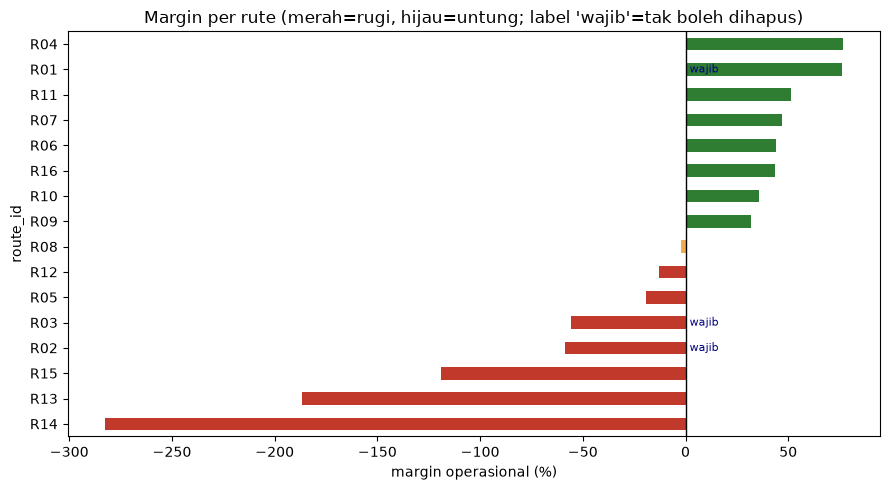

In [5]:
# Margin per rute, diwarnai untung/rugi, rute wajib ditandai
d = D.sort_values("margin_pct")
colors = ["#c0392b" if x<-5 else ("#f0ad4e" if x<5 else "#2e7d32") for x in d.margin_pct]
ax = d.margin_pct.plot(kind="barh", color=colors, figsize=(9,5))
ax.axvline(0, color="k", lw=1)
for i,(rid,row) in enumerate(d.iterrows()):
    if row.route_type=="wajib": ax.text(2, i, "wajib", va="center", fontsize=8, color="navy")
ax.set_xlabel("margin operasional (%)"); ax.set_title("Margin per rute (merah=rugi, hijau=untung; label 'wajib'=tak boleh dihapus)")
plt.tight_layout(); plt.show()

**Pembacaan matriks:**
- **R01, R11 (untung + sering sold-out, ≥22% hari):** permintaan tertekan kapasitas. Konsisten
  dengan sinyal forecast (notebook 02): tambah frekuensi / realokasi kapal lebih besar, bukan
  naikkan harga buta. Ini sumber pertumbuhan utama.
- **R04 (untung paling besar, tapi jarang sold-out ~9%):** margin tebal tanpa tekanan kapasitas;
  pertahankan dan jaga efisiensi, belum perlu ekspansi.
- **R06, R07, R09, R10, R16 (untung, rancangan):** sehat; pertahankan dan jaga efisiensi.
- **R02 (wajib, rugi berat walau LF tinggi):** kasus paling penting. Permintaan sudah penuh tapi
  tetap rugi, jadi ini masalah tarif/biaya, bukan permintaan. Karena `wajib`, opsinya tarif naik
  atau struktur biaya lebih hemat, **bukan** ekspansi (ekspansi justru menambah rugi).
- **R03 (wajib, rugi + sepi):** rugi karena permintaan rendah; wajib jadi tak bisa dihentikan,
  fokus ke penyesuaian frekuensi/kapal agar biaya turun.
- **R05, R12, R13, R14, R15 (rancangan, rugi):** R13/R14/R15 rugi dalam dan sepi, jadi kandidat
  rancang ulang atau hentikan dengan kapalnya direalokasi ke rute sold-out; R05/R12 ruginya tipis
  sehingga perbaikan biaya/tarif mungkin sudah cukup.

## 4. Penyebab biaya pada rute rugi

Untuk rute rugi, komposisi opex menunjukkan tuas mana yang bisa ditekan (bahan bakar lewat
kecepatan/penjadwalan, jasa pelabuhan lewat frekuensi, kru lewat ukuran kapal).

In [6]:
loss = D[D.status=="rugi"].index.tolist()
comp = opex.groupby("route_id")[["fuel_cost_idr","crew_cost_idr","port_fees_idr","maintenance_idr"]].mean()
comp_pct = (comp.div(comp.sum(axis=1), axis=0)*100).round(0)
comp_pct.columns = ["fuel%","crew%","port%","maint%"]
print("Komposisi opex rute rugi (%):")
comp_pct.loc[loss].join(D.loc[loss,["route_type","frequency_per_week"]] if False else routes.set_index("route_id").loc[loss,["frequency_per_week","distance_nm"]])

Komposisi opex rute rugi (%):


,fuel%,crew%,port%,maint%,frequency_per_week,distance_nm
route_id,,,,,,
R02,65.0,5.0,29.0,1.0,96,4.2
R03,54.0,26.0,17.0,2.0,14,31.5
R05,78.0,11.0,7.0,4.0,7,155.3
R12,68.0,23.0,5.0,4.0,4,199.0
R13,71.0,22.0,2.0,4.0,2,426.9
R14,58.0,32.0,5.0,6.0,3,140.0
R15,49.0,42.0,6.0,3.0,5,87.7


Bahan bakar mendominasi di hampir semua rute rugi. Pada R02 (jarak sangat pendek tapi
frekuensi sangat tinggi) jasa pelabuhan ikut besar karena banyaknya keberangkatan, jadi
menggabungkan/menjarangkan keberangkatan bisa menurunkan biaya tanpa kehilangan banyak penumpang.
Pada rute jarak jauh yang sepi (R13/R14), biaya bahan bakar & kru per penumpang tinggi karena
muatan rendah.

## 5. Kaitan ke forecast — proyeksi pendapatan rute padat

Untuk rute padat, forecast permintaan (notebook 02) diubah jadi proyeksi pendapatan ke depan.
Di sini ditampilkan run-rate berdasarkan keterisian 90 hari berlayar terakhir sebagai dasar;
forecast 28-hari berikut interval ketidakpastiannya berasal dari model di notebook 02.

In [7]:
DENSE = ["R01","R02","R04","R11"]
seats = orders[orders.trips>0].groupby("route_id").seats_available.median()
fwd=[]
for r in DENSE:
    s = orders[(orders.route_id==r)&(orders.trips>0)].sort_values("date")
    lf90 = s.load_factor.tail(90).mean()
    sail_pw = routes.set_index("route_id").loc[r,"frequency_per_week"]
    price = pb.set_index("route_id").loc[r,"price_blend"]
    rev_mo = lf90 * seats[r] * price * (sail_pw/7) * 30 / 1e6
    fwd.append(dict(route=r, lf_90hari=round(lf90,3), seats=int(seats[r]),
        rev_runrate_jt=round(rev_mo,0), opex_jt=round(pl.loc[r,"opex"]/1e6,0),
        margin_jt=round(rev_mo-pl.loc[r,"opex"]/1e6,0)))
print("Proyeksi run-rate bulanan rute padat (juta IDR), LF=rata-rata 90 hari berlayar terakhir:")
pd.DataFrame(fwd).set_index("route")

Proyeksi run-rate bulanan rute padat (juta IDR), LF=rata-rata 90 hari berlayar terakhir:


,lf_90hari,seats,rev_runrate_jt,opex_jt,margin_jt
route,,,,,
R01,0.914,14616,341444.0,6513.0,334931.0
R02,0.920,2338,38918.0,4256.0,34662.0
R04,0.812,1137,15795.0,3548.0,12248.0
R11,0.887,2331,19351.0,3028.0,16323.0


Run-rate menegaskan pola yang sama: R01/R11 terisi tinggi dan tertekan kapasitas (kandidat
ekspansi), R04 bermargin besar namun belum sering penuh, sedangkan R02 tetap rugi meski hampir
selalu terisi. Untuk perencanaan, angka ini dipadukan dengan interval prediksi dari notebook 02
agar diperoleh skenario optimis/pesimis, bukan satu angka tunggal.

## 6. Ringkasan rekomendasi & keterbatasan

**Rekomendasi keputusan:**
1. **Ekspansi:** R01, R11 (untung + sering sold-out). Tambah frekuensi atau alihkan kapal
   berkapasitas lebih besar; kapal bisa diambil dari rute rugi-sepi. R04 bermargin besar tapi
   belum sering penuh, jadi dipertahankan tanpa ekspansi dulu.
2. **Rute wajib rugi:** R02 perbaiki tarif/struktur biaya (gabungkan keberangkatan untuk menekan
   jasa pelabuhan), R03 sesuaikan frekuensi/ukuran kapal. Keduanya tidak dihapus sesuai batasan.
3. **Rancang ulang / hentikan:** R13, R14, R15 (rugi dalam + sepi). Realokasikan kapalnya ke rute
   ekspansi. R05, R12 rugi tipis, cukup perbaikan biaya/tarif.
4. **Pertahankan:** R04, R06, R07, R09, R10, R16 sehat; jaga efisiensi bahan bakar.

**Keterbatasan:**
- Pendapatan memakai asumsi bauran kelas (status untung/rugi sudah diuji robust di bagian 2,
  tapi besaran margin tetap bergantung asumsi). Bila tersedia tiket per kelas, angka bisa dipertajam.
- Margin ini operasional; biaya modal/penyusutan dan subsidi PSO untuk rute `wajib` belum dihitung.
- Realokasi kapal di rekomendasi 1 & 3 perlu dicek kelayakan fisik (draft vs alur pelabuhan,
  batas gelombang kapal) dan bentrok jadwal. Itu bahan analisis penugasan armada berikutnya.
- Proyeksi pendapatan run-rate memakai keterisian terkini; versi penuh memakai forecast +
  interval dari notebook 02.